# LAB-P0: Introducción a los sistemas dinámicos computacionales

- **ID de práctica:** LAB-P0-v1.0
- **Capítulo del libro:** Cap. 1 — *An introduction to computational dynamic systems* (Bongers, Gómez y Torres, 2019)
- **Autores:** Antonio F. Romero Carrasco, Anelí Bongers
- **Fecha:** 2026-06-17
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `macroaicomp`)

Modelo de carrera de armamentos de Richardson: un sistema dinámico lineal de
dos ecuaciones que sirve de introducción a los conceptos de estado
estacionario, autovalores y estabilidad antes de abordar modelos
macroeconómicos concretos (IS-LM, Dornbusch, DGE...).

> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
> *   **📋 Antes de empezar**, consulta `GUION.ipynb` (en esta misma carpeta): objetivos, tiempo estimado y conocimientos previos de esta práctica.
>

### 🕹️ GUÍA RÁPIDA DE INICIO - Sistemas Dinámicos
*   **¿Qué estamos haciendo aquí?** Estamos estudiando cómo una variable cambia a lo largo del tiempo usando reglas matemáticas sencillas. Imagina que es el crecimiento de una población o el saldo de tu cuenta bancaria.
*   **Puntos de Equilibrio (Estado Estacionario):** Es el valor donde la variable se queda quieta (no sube ni baja).
*   **Estabilidad:** Si perturbas el sistema (le das un empujón), ¿vuelve al equilibrio (estable) o se dispara al infinito (inestable)?
*   **¡Prueba esto!** Busca donde se definen las matrices o ecuaciones, ejecuta las celdas con `Shift + Enter` y observa cómo las flechas del diagrama de fases te indican hacia dónde viaja el sistema.


In [1]:
%%capture
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # TODO: cuando el repo esté publicado en GitHub, sustituir por
    # %pip install git+https://github.com/<org>/macro-ai-comp.git
    %pip install numpy scipy matplotlib ipywidgets

In [2]:
# "import" trae a este cuaderno código escrito en otro sitio, para no tener
# que reescribirlo. "import X as np" trae toda la librería X y le da un
# alias corto (np) para no tener que teclear el nombre completo cada vez.
# "from X import Y" es más selectivo: trae solo la función/clase Y de X, no
# todo el paquete.

# Librería estándar de Python (viene incluida, no hay que instalarla)
from dataclasses import asdict

# Librerías de terceros (instaladas en el entorno con pip)
import numpy as np                      # cálculo numérico: vectores, matrices, álgebra lineal
from ipywidgets import interact, FloatSlider   # widgets interactivos (sliders) para Jupyter

# Proyecto (requiere `pip install -e .` desde la raíz del repo).
# Separamos en dos módulos a propósito: `arms_race` contiene solo la lógica
# matemática del modelo (matrices, estado estacionario, simulación) y
# `phase_diagram` solo la visualización. Así el notebook se limita a llamar
# funciones ya probadas (ver `tests/python/test_arms_race.py`) en vez de
# reimplementar fórmulas aquí — la celda 10 (Buenas prácticas) vuelve sobre esto.
# Cada nombre entre paréntesis es una función o clase que se podrá usar más
# abajo como si estuviera definida en este mismo cuaderno.
from macroaicomp.models.arms_race import (
    ArmsRaceParams,
    coefficient_matrices,
    eigenvalues,
    is_saddle_path,
    simulate,
    simulate_saddle_path,
    steady_state,
)
from macroaicomp.plotting.phase_diagram import plot_irf, plot_phase_diagram

## 1. Teoría

El modelo se escribe como un sistema dinámico lineal de dos variables
endógenas (ecs. 1.7-1.11 del libro):

$$
\begin{bmatrix} \Delta x_{1,t} \\ \Delta x_{2,t} \end{bmatrix}
= \underbrace{\begin{bmatrix} -\alpha & \beta \\ \gamma & -\delta \end{bmatrix}}_{A}
\begin{bmatrix} x_{1,t} \\ x_{2,t} \end{bmatrix}
+ \underbrace{\begin{bmatrix} \theta & 0 \\ 0 & \eta \end{bmatrix}}_{B}
\begin{bmatrix} z_{1,t} \\ z_{2,t} \end{bmatrix}
$$

donde $x_{1,t}$ y $x_{2,t}$ son el stock de armamento de los países 1 y 2.
El **estado estacionario** es $\bar{\mathbf{x}} = -A^{-1}B\mathbf{z}$ (ec. 1.14),
y la **estabilidad** depende de los autovalores de $A$: el sistema es
globalmente estable si $|\lambda_i + 1| < 1$ para ambos autovalores, y
presenta un **punto de silla** si solo uno de los dos cumple esa condición
(Apéndice A).

## 2. Calibración — Caso 1: estabilidad global (Tablas 1.1 y 1.2)

In [3]:
# Esta celda solo FIJA NÚMEROS (Tabla 1.1 y 1.2 del libro): todavía no
# calcula nada. `ArmsRaceParams` es un dataclass (definido en
# src/macroaicomp/models/arms_race.py): una "ficha" con 6 casillas con
# nombre (alpha, beta, gamma, delta, theta, eta), cada una guardando un
# número. Escribir `ArmsRaceParams(alpha=0.50, ...)` crea un objeto nuevo de
# ese tipo y lo guarda en la variable `params_global`. Usar argumentos CON
# NOMBRE (alpha=0.50 en vez de solo 0.50) evita pasar un valor a la casilla
# equivocada por error de orden — ese bug sí ocurrió en otra práctica del
# proyecto, donde dos parámetros se intercambiaron sin que Python avisara.
# Calibración del Caso 1: estabilidad global (Tabla 1.1 y 1.2 del libro)
params_global = ArmsRaceParams(
    alpha=0.50,  # sensibilidad de Delta x1 a su propio nivel x1
    beta=0.25,   # reacción de Delta x1 al stock de armamento x2
    gamma=0.25,  # reacción de Delta x2 al stock de armamento x1
    delta=0.50,  # sensibilidad de Delta x2 a su propio nivel x2
    theta=1.00,  # impacto de la variable exógena z1 sobre Delta x1
    eta=1.00,    # impacto de la variable exógena z2 sobre Delta x2
)
# np.array([1.0, 1.0]) crea un VECTOR (una lista de números que sabe hacer
# operaciones matemáticas: sumas, productos por matriz...) con dos
# componentes, z1 y z2. Una lista normal de Python ([1.0, 1.0]) no soporta
# esas operaciones; por eso el código del modelo siempre usa np.array.
z_initial = np.array([1.0, 1.0])

# Al ejecutar esta celda solo veremos los 6 valores anteriores impresos como
# diccionario (asdict): es una comprobación visual de que no hay errores de
# tecleo antes de usarlos en ningún cálculo. asdict() convierte el objeto
# ArmsRaceParams en un diccionario {nombre: valor} solo para que se imprima
# de forma legible — no cambia los datos en sí.
asdict(params_global)

{'alpha': 0.5,
 'beta': 0.25,
 'gamma': 0.25,
 'delta': 0.5,
 'theta': 1.0,
 'eta': 1.0}

## 3. Resolución: estado estacionario y estabilidad

In [4]:
# steady_state() es una FUNCIÓN: le pasamos dos argumentos entre paréntesis
# (params_global, z_initial) y nos devuelve un resultado, que aquí guardamos
# en la variable x_bar con "=". Por dentro resuelve x_bar = -A^{-1} B z
# (ec. 1.14): el punto donde Delta x1 = Delta x2 = 0, es decir, donde
# ninguno de los dos países cambia ya su stock de armamento. No necesitamos
# saber CÓMO lo calcula para usarla: solo qué entra y qué sale (eso es la
# "caja negra" de una función bien documentada, ver su docstring en
# src/macroaicomp/models/arms_race.py).
x_bar = steady_state(params_global, z_initial)
# eigenvalues() da los autovalores de A. Lo que importa para la estabilidad
# no es su signo sino el módulo |lambda + 1| (Apéndice A): si es < 1 para
# AMBOS autovalores, cualquier perturbación se amortigua y el sistema vuelve
# al estado estacionario (estabilidad global); si solo uno cumple esa
# condición, es un punto de silla (lo veremos en la Sección 8).
lambdas = eigenvalues(params_global)

# Las cadenas con "f" delante (f-strings) permiten meter el valor de una
# variable dentro de un texto escribiéndola entre llaves {}. round(2) y
# np.round(..., 2) redondean a 2 decimales SOLO para que se imprima más
# corto: el valor real guardado en la variable no cambia.
print(f"Estado estacionario (x1_bar, x2_bar) = {x_bar.round(2)}")
# sorted() ordena los dos autovalores de menor a mayor, para que siempre se
# impriman en el mismo orden sin importar en qué orden los devuelva NumPy.
print(f"Autovalores (lambda1, lambda2)        = {np.round(sorted(lambdas), 2)}")
print(f"Moduli |lambda + 1|                   = {np.round(np.abs(np.sort(lambdas) + 1), 2)}")
print(f"Punto de silla                        = {is_saddle_path(params_global)}")
# Resultado esperado con esta calibración: SS en (4, 4), autovalores
# negativos con módulo < 1 (estabilidad global) y punto de silla = False.

Estado estacionario (x1_bar, x2_bar) = [4. 4.]
Autovalores (lambda1, lambda2)        = [-0.75 -0.25]
Moduli |lambda + 1|                   = [0.25 0.75]
Punto de silla                        = False


## 4. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y reproducidos por el
código MATLAB del Apéndice B (`referencia/m1.m`), recogidos en
`oraculo.md`: estado estacionario $(4, 4)$ y autovalores $(-0.25, -0.75)$.

**Caso 1 — Calibración base (Tabla 1.1: α=0.50, β=0.25, γ=0.25, δ=0.50, θ=1.00, η=1.00; z₁=z₂=1):**

| Magnitud | Valor esperado (oráculo) |
|---|---|
| Estado estacionario inicial $(\bar x_1, \bar x_2)$ | (4, 4) |
| Autovalores $(\lambda_1, \lambda_2)$ | (−0.25, −0.75) |
| Nuevo SS tras shock $z_1: 1 \to 2$ (Sección 5) | (6.67, 5.33) |
| Nuevo SS tras sensibilidad $\alpha: 0.50 \to 0.70$ (Sección 7) | (2.61, 3.30) |

Así puedes comparar a simple vista, sin abrir `oraculo.md`, el número que
debería salir en cada celda siguiente con el que realmente sale.

In [5]:
# np.testing.assert_allclose(a, b, atol=...) compara dos valores (o dos
# vectores, elemento a elemento) y SOLO lanza un error si la diferencia
# supera la tolerancia atol. No usamos "==" porque el ordenador casi nunca
# da resultados EXACTAMENTE iguales en aritmética con decimales (errores de
# redondeo internos), aunque la fórmula esté bien aplicada — comparar con un
# margen pequeño es la forma correcta de verificar números reales.
# Si la comparación pasa, assert_allclose no hace nada (no imprime nada): es
# un PUNTO DE CONTROL silencioso. Si el port a Python tuviera un error, esta
# celda lanzaría AssertionError y detendría la ejecución aquí mismo, antes
# de seguir construyendo gráficos sobre un resultado incorrecto.
np.testing.assert_allclose(x_bar, [4.0, 4.0], atol=1e-6)
np.testing.assert_allclose(sorted(lambdas), [-0.75, -0.25], atol=1e-6)
print("OK: coincide con el oráculo MATLAB (Apéndice B).")

OK: coincide con el oráculo MATLAB (Apéndice B).


## 5. Análisis de shock (Sección 1.5)

Aumentamos la variable exógena $z_1$ de 1 a 2 y observamos la transición
hacia el nuevo estado estacionario.

Nuevo estado estacionario (x1_bar, x2_bar) = (6.67, 5.33)  (esperado: 6.67, 5.33)


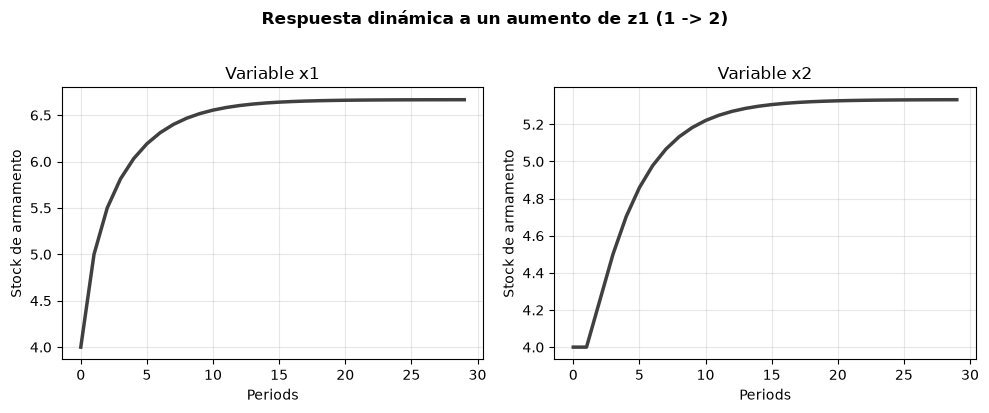

In [6]:
# A partir de aquí cambiamos la variable exógena: el país 1 pasa de z1=1 a
# z1=2 (más hostilidad/gasto autónomo). simulate() reproduce la recursión
# periodo a periodo x[t+1] = x[t] + (A@x[t] + B@z_t), empezando en el SS
# anterior y usando z_final desde el primer periodo (shock_period=1 por
# defecto) — no resuelve el nuevo SS de golpe, lo alcanza simulando.
# simulate() devuelve DOS resultados a la vez (una "tupla" de 2 arrays).
# Escribir dos nombres separados por coma a la izquierda del "=" hace que
# Python reparta esa tupla: x1_path recibe el primero, x2_path el segundo.
z_final_shock = np.array([2.0, 1.0])
x1_path, x2_path = simulate(params_global, z_initial, z_final_shock, periods=30)

# x1_path[-1] usa indexado negativo: -1 significa "el último elemento del
# array" (en vez de tener que saber cuántos hay, como con x1_path[29]).
print(f"Nuevo estado estacionario (x1_bar, x2_bar) = "
      f"({x1_path[-1]:.2f}, {x2_path[-1]:.2f})  (esperado: 6.67, 5.33)")

# plot_irf() dibuja un subplot por variable. Como la calibración es
# globalmente estable, la trayectoria debería verse monótona y convergente
# (sin oscilar) hacia el nuevo SS, alcanzándolo hacia el periodo ~15.
fig = plot_irf(x1_path, x2_path, ylabel="Stock de armamento",
             suptitle="Respuesta dinámica a un aumento de z1 (1 -> 2)")
# El ";" al final de esta línea le dice a Jupyter que NO imprima también la
# representación de texto del objeto fig devuelto (algo como
# "<Figure size 1000x400...>") debajo del propio gráfico; sin el ";" verías
# esa línea de texto duplicada justo encima de la figura.
fig;

## 6. Diagrama de fases (Figura B.1 del Apéndice B)

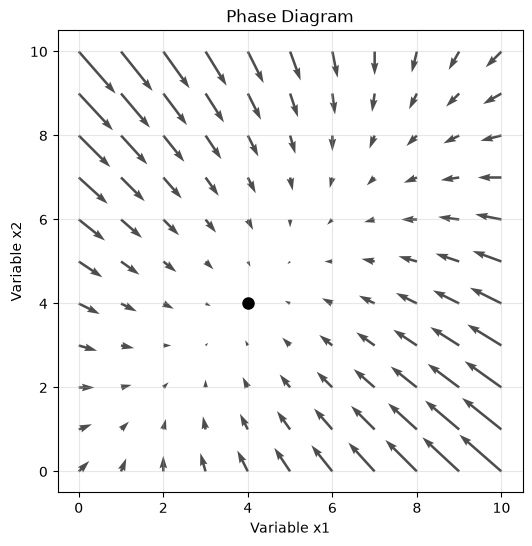

In [7]:
# coefficient_matrices() reconstruye A y B (ec. 1.7-1.8) a partir de los
# mismos parámetros — las necesitamos sueltas porque plot_phase_diagram()
# dibuja el campo vectorial Delta x = A@x + B@z en cada punto de una malla
# (x1, x2), no solo en la trayectoria simulada. Como en la celda anterior,
# "a, b = ..." reparte la tupla devuelta en dos variables: a recibe la
# primera matriz, b la segunda.
a, b = coefficient_matrices(params_global)
# Cada flecha del gráfico indica hacia dónde "empuja" el sistema desde ese
# punto; el punto negro marca el estado estacionario (x_bar). Si todas las
# flechas alrededor apuntan hacia ese punto, es estable — exactamente lo que
# esperamos aquí, reproduciendo la Figura B.1 del Apéndice B.
fig = plot_phase_diagram(a, b, z_initial, steady_state_point=x_bar, labels=("x1", "x2"))
fig;

## 7. Análisis de sensibilidad (Sección 1.6.1)

Aumentamos $\alpha$ de 0.50 a 0.70: el país 1 se vuelve más sensible a su
propio stock de armamento, lo que reduce el estado estacionario de ambos
países y rompe la simetría entre ellos.

In [8]:
# Repetimos el mismo cálculo de la Sección 3 (steady_state + eigenvalues)
# pero con alpha más alto. Interpretación económica: alpha mide cuánto le
# "pesa" al país 1 su propio stock de armamento (fatiga/coste de
# mantenimiento) — si sube, el país 1 modera su propia carrera armamentística,
# lo que reduce SU estado estacionario y, por la interacción del sistema,
# también el del país 2 (que ya no necesita responder a tanto armamento).
# Como ya no es alpha=delta, además se rompe la simetría x1_bar=x2_bar del Caso 1.
# Creamos un ArmsRaceParams NUEVO en vez de modificar params_global: así la
# celda 6 sigue siendo válida más abajo si volvemos a ejecutarla, y queda
# claro en el nombre de la variable (params_sensitivity) que es una
# calibración distinta, no una corrección de la anterior.
params_sensitivity = ArmsRaceParams(
    alpha=0.70, beta=0.25, gamma=0.25, delta=0.50, theta=1.00, eta=1.00
)
x_bar_sensitivity = steady_state(params_sensitivity, z_initial)
lambdas_sensitivity = eigenvalues(params_sensitivity)

print(f"Estado estacionario (x1_bar, x2_bar) = {x_bar_sensitivity.round(2)} "
      f"(esperado: 2.61, 3.30)")
print(f"Autovalores                          = {np.round(sorted(lambdas_sensitivity), 2)} "
      f"(esperado: -0.87, -0.33)")
print(f"Punto de silla                       = {is_saddle_path(params_sensitivity)} "
      f"(esperado: False, sigue siendo estable)")

# Igual que en la celda 10: si el cálculo no coincide con el oráculo, esta
# celda detiene la ejecución con AssertionError en vez de dejar pasar un
# resultado numérico incorrecto.
np.testing.assert_allclose(x_bar_sensitivity, [2.61, 3.30], atol=1e-2)
np.testing.assert_allclose(sorted(lambdas_sensitivity), [-0.87, -0.33], atol=1e-2)

Estado estacionario (x1_bar, x2_bar) = [2.61 3.3 ] (esperado: 2.61, 3.30)
Autovalores                          = [-0.87 -0.33] (esperado: -0.87, -0.33)
Punto de silla                       = False (esperado: False, sigue siendo estable)


## 8. Punto de silla (Sección 1.6.2)

Con $\beta, \gamma > \alpha, \delta$ (Tabla 1.3) el sistema tiene un
autovalor estable y otro inestable: el estado estacionario es un punto de
silla. La variable $x_1$ se asume "de salto" (forward-looking) y se
reajusta instantáneamente sobre la senda estable ante una perturbación
(ec. 1.39), mientras $x_2$ evoluciona de forma estándar.

**Caso 2 — Calibración de punto de silla (Tabla 1.3: α=0.25, β=0.50, γ=0.50, δ=0.25; z₁=z₂=−1 → z₁=−0.5):**

| Magnitud | Valor esperado (oráculo) |
|---|---|
| Estado estacionario inicial $(\bar x_1, \bar x_2)$ | (4, 4) |
| Autovalores $(\lambda_1, \lambda_2)$ | (−0.75, 0.25) — uno estable y otro inestable |
| Salto instantáneo de $x_1$ en el periodo del shock | 2.00 |
| Nuevo estado estacionario $(\bar x_1, \bar x_2)$ | (3.33, 2.67) |

Punto de silla = True (esperado: True)
Salto instantáneo de x1 en el periodo del shock = 2.00 (esperado: 2.00)
Nuevo estado estacionario (x1, x2) = (3.33, 2.67)  (esperado: 3.33, 2.67)


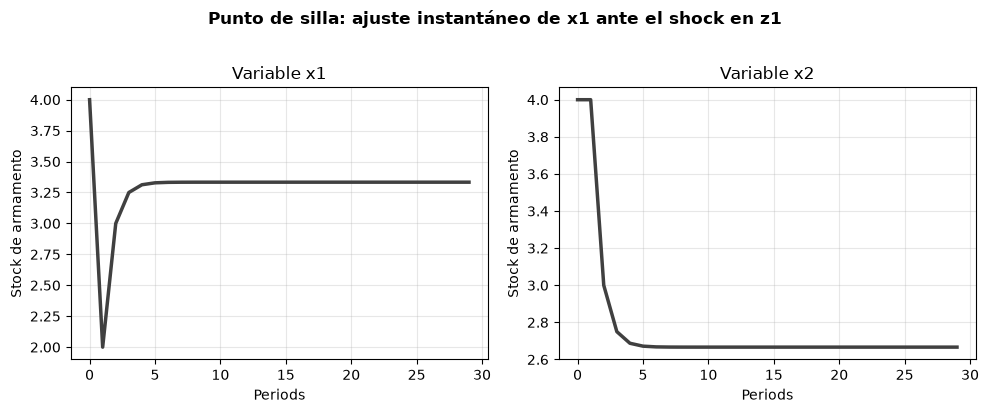

In [9]:
params_saddle = ArmsRaceParams(
    alpha=0.25, beta=0.50, gamma=0.50, delta=0.25, theta=1.00, eta=1.00
)
z_initial_saddle = np.array([-1.0, -1.0])
z_final_saddle = np.array([-0.5, -1.0])

# Confirmamos que esta calibración SÍ produce un punto de silla antes de
# llamar a simulate_saddle_path() (esa función lanzaría ValueError si no lo fuera).
print(f"Punto de silla = {is_saddle_path(params_saddle)} (esperado: True)")

# simulate_saddle_path() trata las dos variables de forma distinta en el
# periodo del shock (jump_variable=0 -> x1 es la variable de salto, usando
# el índice 0 porque Python empieza a contar las posiciones en 0, no en 1):
# 1) x2 (predeterminada) sigue evolucionando con su valor anterior, como en
#    simulate(); 2) x1 (forward-looking) NO usa la recursión estándar, sino
# que se recalcula para caer exactamente sobre la senda estable asociada al
# autovalor estable — por eso "salta" en un solo periodo en vez de converger
# gradualmente.
x1_saddle, x2_saddle = simulate_saddle_path(
    params_saddle, z_initial_saddle, z_final_saddle, periods=30, jump_variable=0
)

# x1_saddle[1] es el SEGUNDO elemento del array (recuerda: en Python el
# primer elemento es x1_saddle[0]). Como el shock ocurre en shock_period=1
# y el array empieza en el periodo 0 (el estado estacionario inicial),
# x1_saddle[1] es justo el periodo donde x1 da su salto.
print(f"Salto instantáneo de x1 en el periodo del shock = {x1_saddle[1]:.2f} (esperado: 2.00)")
print(f"Nuevo estado estacionario (x1, x2) = "
      f"({x1_saddle[-1]:.2f}, {x2_saddle[-1]:.2f})  (esperado: 3.33, 2.67)")

np.testing.assert_allclose(x1_saddle[1], 2.0, atol=1e-2)
# Aquí comparamos una LISTA de dos valores [x1_saddle[-1], x2_saddle[-1]]
# contra otra lista [3.33, 2.67]: assert_allclose compara posición a
# posición (el primero contra el primero, el segundo contra el segundo).
np.testing.assert_allclose([x1_saddle[-1], x2_saddle[-1]], [3.33, 2.67], atol=1e-2)

# En el gráfico, x1 debería mostrar un escalón brusco en el periodo 1 (el
# salto) y luego converger con normalidad junto a x2.
fig = plot_irf(x1_saddle, x2_saddle, ylabel="Stock de armamento",
             suptitle="Punto de silla: ajuste instantáneo de x1 ante el shock en z1")
fig;

## 9. Widget interactivo — sensibilidad al shock de z1

Mueve el slider para comprobar cómo cambia la trayectoria de ambas
variables según la magnitud del shock sobre $z_1$ (calibración de
estabilidad global, Caso 1).

In [10]:
# "def nombre(argumentos):" define una FUNCIÓN: un bloque de código
# reutilizable que no se ejecuta al escribirlo, solo cuando alguien lo
# "llama" más abajo (interact() lo llama por nosotros). z1_final: float = 2.0
# declara un argumento con un VALOR POR DEFECTO (2.0): si se llama a
# _plot_shock() sin indicar z1_final, usará 2.0. El guion bajo inicial
# (_plot_shock) es solo una convención: avisa a quien lea el código de que
# esta función es de uso interno de esta celda, no pensada para importarse
# desde otro notebook.
def _plot_shock(z1_final: float = 2.0):
    x1_path, x2_path = simulate(params_global, z_initial, np.array([z1_final, 1.0]), periods=30)
    fig = plot_irf(x1_path, x2_path, ylabel="Stock de armamento",
             suptitle=f"Shock z1: 1 -> {z1_final:.2f}")


# interact() conecta esa función a un FloatSlider: cada vez que mueves el
# slider en el navegador, ipywidgets vuelve a llamar a _plot_shock() con el
# nuevo valor de z1_final y redibuja la figura — no hay que ejecutar la
# celda de nuevo. El nombre del argumento (z1_final=...) tiene que coincidir
# exactamente con el de la definición de la función para que interact() sepa
# qué argumento está controlando el slider. Útil para ver en vivo cómo la
# magnitud del shock cambia el nuevo estado estacionario y la velocidad de
# convergencia.
interact(_plot_shock, z1_final=FloatSlider(value=2.0, min=-2.0, max=4.0, step=0.25));

interactive(children=(FloatSlider(value=2.0, description='z1_final', max=4.0, min=-2.0, step=0.25), Output()),…

## 10. Buenas prácticas aplicadas aquí

Observa que `steady_state()`, `eigenvalues()`, `simulate()` y
`simulate_saddle_path()` están documentadas con docstrings NumPy, tienen
type hints y viven en `src/macroaicomp/models/arms_race.py` — no en este
notebook. La lógica del modelo está separada de la visualización
(`src/macroaicomp/plotting/phase_diagram.py`). Cuando hagas tu ABP, haz lo
mismo: funciones reutilizables a `src/`, el notebook solo para exponer y
narrar el análisis.

## 11. Conclusión

El mismo sistema dinámico lineal puede mostrar dos comportamientos
cualitativamente distintos según el valor de sus parámetros: estabilidad
global, donde toda perturbación converge suavemente al nuevo equilibrio, o
un punto de silla, donde una variable debe "saltar" instantáneamente para
mantener la convergencia. Esta distinción —y el procedimiento para
detectarla a partir de los autovalores de $A$— es la base que reutilizaremos
en el resto de prácticas (IS-LM dinámico, Dornbusch, DGE) cuando los
sistemas dejen de ser ejemplos genéricos y representen economías reales.
Los resultados numéricos coinciden exactamente con el oráculo MATLAB del
Apéndice B, lo que valida el port a Python.

**📋 Para terminar**, responde el cuestionario de bitácora de `GUION.ipynb`
(en esta misma carpeta) y, si quieres ir más allá, prueba alguna de sus
extensiones para ABP.